<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import os
import random

torch.__version__

'2.10.0+cu128'

In [7]:
data = Path("/content/drive/MyDrive/animals (1)")
train_path = data/"Train"
test_path = data/"Test"
train_path, test_path

(PosixPath('/content/drive/MyDrive/animals (1)/Train'),
 PosixPath('/content/drive/MyDrive/animals (1)/Test'))

In [8]:
for dirpath, dirnames, filenames in os.walk(data):
  print(f"dirpath: {dirpath}, dirnames: {dirnames}, filenames: {len(filenames)}")

dirpath: /content/drive/MyDrive/animals (1), dirnames: ['Test', 'Train'], filenames: 0
dirpath: /content/drive/MyDrive/animals (1)/Test, dirnames: ['dog', 'cat'], filenames: 0
dirpath: /content/drive/MyDrive/animals (1)/Test/dog, dirnames: [], filenames: 100
dirpath: /content/drive/MyDrive/animals (1)/Test/cat, dirnames: [], filenames: 100
dirpath: /content/drive/MyDrive/animals (1)/Train, dirnames: ['dog', 'cat'], filenames: 0
dirpath: /content/drive/MyDrive/animals (1)/Train/dog, dirnames: [], filenames: 400
dirpath: /content/drive/MyDrive/animals (1)/Train/cat, dirnames: [], filenames: 400


In [9]:
all_img = list(data.glob("*/*/*.png"))
len(all_img)

1000

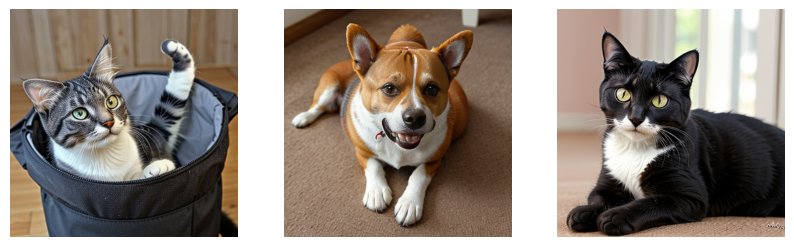

In [11]:
R_ImgPaths = random.sample(all_img, k=3)
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

for i, i_path in enumerate(R_ImgPaths):
  img = Image.open(i_path)
  ax[i].imshow(img)
  ax[i].axis("off")

In [15]:
data_transfom = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.RandomAutocontrast(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.TrivialAugmentWide(num_magnitude_bins=30)
])

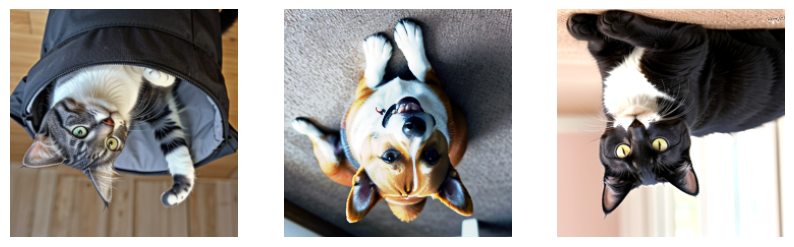

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))

for i, i_path in enumerate(R_ImgPaths):
  img = Image.open(i_path)
  trans_img = data_transfom(img)
  ax[i].imshow(trans_img)
  ax[i].axis("off")

In [17]:
data_transfom = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.RandomAutocontrast(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.TrivialAugmentWide(num_magnitude_bins=30),
    transforms.ToTensor()
])
data_transfom

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomAutocontrast(p=0.5)
    RandomVerticalFlip(p=0.5)
    TrivialAugmentWide(num_magnitude_bins=30, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
)

In [18]:
train_dataset = datasets.ImageFolder(train_path, transform=data_transfom)
test_dataset = datasets.ImageFolder(test_path, transform=data_transfom)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [19]:
classes = train_dataset.classes
class_idx = train_dataset.class_to_idx
classes, class_idx

(['cat', 'dog'], {'cat': 0, 'dog': 1})

In [20]:
B_IMG, B_LBL = next(iter(train_dataloader))
B_IMG.shape, B_LBL

(torch.Size([32, 3, 224, 224]),
 tensor([1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
         0, 1, 1, 1, 1, 0, 0, 1]))

In [21]:
from torchvision.models import resnet18

model = resnet18()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
for params in model.parameters():
  params.requires_grad = False

In [26]:
from torch import nn

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

In [27]:
model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-1.1296e-02,  3.1543e-03, -7.1320e-03,  ..., -2.5907e-03,
                          1.4236e-03,  2.6961e-02],
                        [-1.3416e-02,  2.6194e-02,  5.1864e-03,  ..., -1.3515e-02,
                          3.1648e-02,  1.1473e-02],
                        [-1.0781e-02,  2.7513e-02,  1.6961e-02,  ..., -8.0768e-03,
                          4.3695e-02,  1.2892e-02],
                        ...,
                        [-3.1254e-02, -9.8063e-03, -2.5115e-02,  ...,  2.1407e-03,
                          6.4607e-03,  1.6581e-02],
                        [-3.9675e-03,  1.0832e-02, -2.2316e-02,  ...,  4.6577e-03,
                         -5.1049e-02,  2.7583e-02],
                        [ 8.3100e-03, -3.9317e-02, -1.6542e-02,  ..., -4.0204e-02,
                         -7.3865e-03, -1.1998e-02]],
              
                       [[ 1.0824e-02, -4.9480e-02,  2.4616e-02,  ...,  6.2201e-02,
                          2.6752

In [30]:
test_img = B_IMG[0].unsqueeze(0)
test_img.shape, B_LBL[0]

(torch.Size([1, 3, 224, 224]), tensor(1))

In [31]:
with torch.inference_mode():
  pred = model(test_img)

torch.round(torch.sigmoid(pred))

tensor([[1.]])

In [32]:
from torch.nn import BCEWithLogitsLoss
from torch.optim import Adam

criterion = BCEWithLogitsLoss()
optimizer = Adam(params=model.parameters(), lr=0.001)

In [33]:
from tqdm import tqdm

In [37]:
for epoch in tqdm(range(2)):
  model.train()
  train_loss = 0
  for img, label in train_dataloader:
    logits = model(img)
    pred = torch.round(torch.sigmoid(logits))
    loss = criterion(logits.squeeze(1), label.float())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  print(f"\n__Epoch__{epoch}\n")
  print(f"Loss: {train_loss/len(train_dataloader):.5f}")

 50%|█████     | 1/2 [05:33<05:33, 333.14s/it]


__Epoch__0

Loss: 0.69652


100%|██████████| 2/2 [06:39<00:00, 199.78s/it]


__Epoch__1

Loss: 0.69916


In [38]:
TE_BATCH, TE_LBL = next(iter(test_dataloader))
teImage = TE_BATCH[0].unsqueeze(0)
teImage.shape, TE_LBL[0]

(torch.Size([1, 3, 224, 224]), tensor(0))

In [40]:
img = teImage.squeeze(0)
img = img.permute(1, 2, 0)
img.shape

torch.Size([224, 224, 3])

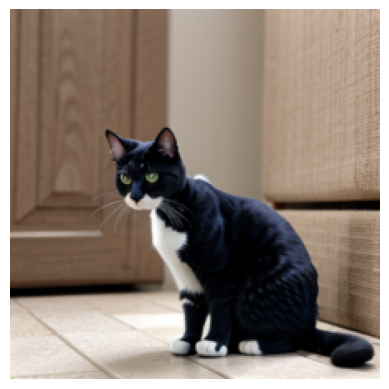

In [42]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [43]:
with torch.inference_mode():
  pred = model(teImage)

prediction = torch.round(torch.sigmoid(pred))

In [47]:
predicted_class = classes[int(prediction)]
print(predicted_class)

cat
